In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel

In [ ]:
class MarksState(TypedDict):

    social_science: float
    science: float
    maths: float
    hindi: float
    english: float
    

class CalculationState(TypedDict):

    result_social_science: bool
    result_science: bool
    result_maths: bool
    result_hindi: bool
    result_english: bool
    avg_result: float

class ResultState(TypedDict):

    result: str
    final_score: float

In [27]:
def calculation(state: MarksState) -> CalculationState:
    ss, s, m, e, h = True, True, True, True, True
    if state["social_science"] < 33:
        ss = False
    if state["science"] < 33:
        s = False
    if state["maths"] < 33:
        m = False
    if state["english"] < 33:
        e = False
    if state["hindi"] < 33:
        h = False
    avg = sum(state.values())/len(state.keys())
    
    return {"result_social_science":ss, "result_science": s, "result_maths": m, "result_hindi": h, "result_english": e, "avg_result":avg}

def result(state: CalculationState) -> ResultState:
    if state["result_social_science"] and state["result_science"] and state["result_maths"] and state["result_hindi"] and state["result_english"]:
        return {"result": "pass", "final_score": state["avg_result"]}
    else:
        return {"result": "failed" , "final_score": state["avg_result"]}

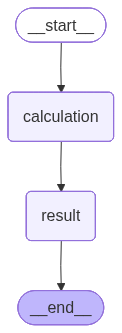

In [ ]:
graph = StateGraph(MarksState, input=MarksState, output=ResultState)

graph.add_node("calculation", calculation)
graph.add_node("result", result)

graph.add_edge(START, "calculation")
graph.add_edge("calculation","result")
graph.add_edge("result", END)

wf = graph.compile()
wf

In [31]:
wf.invoke({"social_science":45, "science": 67, "maths": 88, "english": 56, "hindi": 78})

{'social_science': 45,
 'science': 67,
 'maths': 88,
 'hindi': 78,
 'english': 56,
 'result': 'pass',
 'final_score': 66.8}